<a href="https://colab.research.google.com/github/Yashbaghel12/sbc/blob/main/solarsystemgnns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch-geometric


In [ ]:
import numpy as np

def n_body_derivatives(t, state):
    # Ensure state is a flat 1D numpy array of 12 elements (3 bodies * 4 features)
    state = np.asarray(state).flatten()

    # Reshape to easily slice positions and velocities: shape (3, 4)
    current_state = state.reshape(3, 4)
    derivatives = np.zeros((3, 4))

    # HARDCODED TRADITIONAL MASSES (Star=100, Planet 1=1, Planet 2=1.5)
    # This prevents the simulator from accidentally pulling a neural tensor mass
    sim_masses = [100.0, 1.0, 1.5]
    G = 1.0  # Gravitational constant

    for i in range(3):
        # Velocity derivatives are just the current velocities (dx/dt = vx, dy/dt = vy)
        derivatives[i, 0:2] = current_state[i, 2:4]

        ax = 0.0
        ay = 0.0

        for j in range(3):
            if i == j:
                continue

            # Calculate explicit vector differences
            dx = float(current_state[j, 0] - current_state[i, 0])
            dy = float(current_state[j, 1] - current_state[i, 1])

            r = np.sqrt(dx**2 + dy**2) + 1e-6

            # Acceleration contribution (Newton's Law)
            # Forcing outputs to be explicit float scalars
            ax += float(G * sim_masses[j] * dx / r**3)
            ay += float(G * sim_masses[j] * dy / r**3)

        # Pack acceleration back into derivatives matrix safely
        derivatives[i, 2] = ax
        derivatives[i, 3] = ay

    # solve_ivp demands a completely flat 1D output vector (12,)
    return derivatives.flatten()

In [ ]:
import torch
import torch.nn as nn
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing

class PurePhysicsDataset(Dataset):
    def __init__(self, sim_data):
        super().__init__()
        # We use the RAW un-normalized simulation data directly!
        self.sim_data = torch.tensor(sim_data, dtype=torch.float32)
        self.num_frames = len(sim_data) - 1
        self.edge_index = torch.tensor([[0, 0, 1, 1, 2, 2],
                                        [1, 2, 0, 2, 0, 1]], dtype=torch.long)

    def len(self):
        return self.num_frames

    def get(self, idx):
        current_frame = self.sim_data[idx]
        next_frame = self.sim_data[idx + 1]

        dt = 0.01
        accel_target = (next_frame[:, 2:4] - current_frame[:, 2:4]) / dt
        node_ids = torch.tensor([0, 1, 2], dtype=torch.long)

        return Data(x=current_frame, edge_index=self.edge_index, y=accel_target, node_id=node_ids)

dataset = PurePhysicsDataset(data)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

class PureInteractionNetwork(MessagePassing):
    def __init__(self):
        super().__init__(aggr='add')

        # Explicit learnable parameters for the 3 masses (initialized to 1.0)
        self.learned_masses = nn.Parameter(torch.ones(3, 1))

        # Edge MLP: ONLY allowed to look at [distance r, mass_i, mass_j] -> 3 inputs total!
        self.edge_mlp = nn.Sequential(
            nn.Linear(3, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1) # Outputs a simple scalar force magnitude
        )

    def forward(self, x, edge_index, node_id):
        return self.propagate(edge_index, x=x, node_id=node_id)

    def message(self, x_i, x_j, edge_index, node_id):
        # Calculate explicit distance components r
        delta_pos = x_j[:, 0:2] - x_i[:, 0:2]
        r = torch.norm(delta_pos, dim=-1, keepdim=True) + 1e-6
        unit_direction = delta_pos / r

        # Grab the corresponding learnable masses for the interacting nodes
        row, col = edge_index
        m_i = self.learned_masses[node_id[row]]
        m_j = self.learned_masses[node_id[col]]

        # Feed exactly [r, m_i, m_j] to the network
        mlp_inputs = torch.cat([r, m_i, m_j], dim=-1)
        force_magnitude = self.edge_mlp(mlp_inputs)

        # The force vector acts directly along the direction line
        return force_magnitude * unit_direction

    def update(self, aggr_out, node_id):
        # Acceleration = Net Force / Mass
        m_i = self.learned_masses[node_id]
        return aggr_out / m_i

print("Explicit Geometry GNN initialized!")

Explicit Geometry GNN initialized!


In [ ]:
# Check if Colab allocated a free GPU hardware accelerator, otherwise use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PureInteractionNetwork().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

model.train()
for epoch in range(1, 101):
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        out = model(batch.x, batch.edge_index, batch.node_id)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | Loss: {total_loss / len(dataset):.6f}")

Epoch   1 | Loss: 468.063004
Epoch  10 | Loss: 37.391759
Epoch  20 | Loss: 4.864621
Epoch  30 | Loss: 1.705242
Epoch  40 | Loss: 1.195212
Epoch  50 | Loss: 1.041140
Epoch  60 | Loss: 0.974696
Epoch  70 | Loss: 0.943047
Epoch  80 | Loss: 0.914371
Epoch  90 | Loss: 0.907412
Epoch 100 | Loss: 0.900984


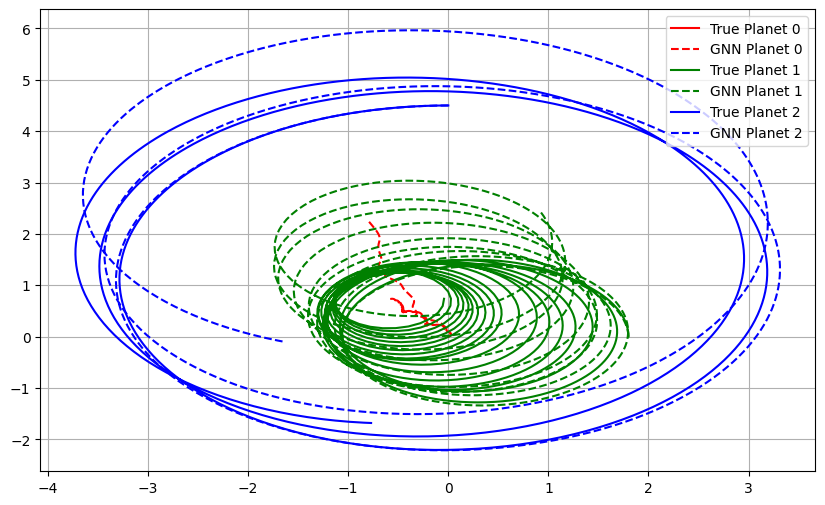

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

v_state0 = [0.0, 0.0, 0.0, 0.0]
v_state1 = [1.8, 0.0, 0.0, 6.5]
v_state2 = [0.0, 4.5, -4.0, 0.0]
new_initial_state = np.concatenate([v_state0, v_state1, v_state2])

sol_val = solve_ivp(n_body_derivatives, t_span, new_initial_state, t_eval=t_eval, method='RK45')
val_data = sol_val.y.T.reshape(len(t_eval), 3, 4)

model.eval()
gnn_positions = [val_data[0, :, 0:2]]
current_features = torch.tensor(val_data[0], dtype=torch.float32).to(device)
edge_index = torch.tensor([[0, 0, 1, 1, 2, 2], [1, 2, 0, 2, 0, 1]], dtype=torch.long).to(device)
val_node_ids = torch.tensor([0, 1, 2], dtype=torch.long).to(device)

dt = 0.01
with torch.no_grad():
    for t in range(len(t_eval) - 1):
        # Clean and direct: no scalar translation adjustments needed!
        pred_accel = model(current_features, edge_index, val_node_ids).cpu().numpy()

        pos = current_features[:, 0:2].cpu().numpy()
        vel = current_features[:, 2:4].cpu().numpy()
        next_vel = vel + pred_accel * dt
        next_pos = pos + next_vel * dt
        gnn_positions.append(next_pos)
        current_features = torch.tensor(np.hstack([next_pos, next_vel]), dtype=torch.float32).to(device)

gnn_positions = np.array(gnn_positions)
plt.figure(figsize=(10, 6))
colors = ['r', 'g', 'b']
for i in range(3):
    plt.plot(val_data[:, i, 0], val_data[:, i, 1], label=f'True Planet {i}', color=colors[i], linestyle='-')
    plt.plot(gnn_positions[:, i, 0], gnn_positions[:, i, 1], label=f'GNN Planet {i}', color=colors[i], linestyle='--')
plt.legend(); plt.grid(True); plt.show()

In [ ]:
!pip install -U pysr


  Using cached pysr-1.5.10-py3-none-any.whl.metadata (54 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 17.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import torch
from pysr import PySRRegressor

# 1. Sample actual pairs directly from your raw dataset
num_samples = len(dataset)
r_list = []
f_list = []

model.eval()
with torch.no_grad():
    for i in range(num_samples):
        graph = dataset[i]

        # Move inputs to device
        x_dev = graph.x.to(device)
        edge_index_dev = graph.edge_index.to(device)
        val_node_ids = graph.node_id.to(device)

        # Replicate the exact mathematical inputs passed to the edge_mlp
        row, col = edge_index_dev

        # Extract distance component r
        delta_pos = x_dev[col, 0:2] - x_dev[row, 0:2]
        r_tensor = torch.norm(delta_pos, dim=-1, keepdim=True) + 1e-6

        # Extract the explicit learned masses
        m_i = model.learned_masses[val_node_ids[row]]
        m_j = model.learned_masses[val_node_ids[col]]

        # Combine exactly how the edge_mlp expects them: [r, m_i, m_j]
        mlp_inputs = torch.cat([r_tensor, m_i, m_j], dim=-1)

        # Harvest the scalar force magnitude predicted by the network
        force_magnitude = model.edge_mlp(mlp_inputs).cpu().numpy()
        r_vals = r_tensor.cpu().numpy()

        for idx in range(len(force_magnitude)):
            r_list.append(r_vals[idx, 0])
            f_list.append(force_magnitude[idx, 0])

X_r = np.array(r_list).reshape(-1, 1)
y_f = np.array(f_list)

# 2. Run PySR on the pristine, isolated scalar space
pysr_agent = PySRRegressor(
    niterations=40,
    binary_operators=["+", "*", "/"],
    unary_operators=["inv(x) = 1/x"],
    extra_sympy_mappings={"inv": lambda x: 1 / x},
    model_selection="best"
)

print("Running Symbolic Regression on Unconstrained Scalar Force Spaces...")
pysr_agent.fit(X_r, y_f)

print("\n--- BRAND NEW DISCOVERED SCOREBOARD ---")
print(pysr_agent.equations_)

Running Symbolic Regression on Unconstrained Scalar Force Spaces...


/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 2.810e+04
Progress: 122 / 1240 total iterations (9.839%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.857e+01  0.000e+00  y = 4.8553
3           6.018e+01  1.333e-01  y = 13.12 / x₀
5           5.543e+01  4.111e-02  y = (22.115 / x₀) + -4.9474
7           5.517e+01  2.367e-03  y = (40.449 / (x₀ + x₀)) / x₀
9           5.513e+01  2.769e-04  y = (((x₀ + 19.644) / x₀) / x₀) + -0.37674
11          5.506e+01  6.644e-04  y = (((x₀ + 26.81) / (x₀ + 0.4002)) / x₀) + -0.7684
12          5.472e+01  6.240e-03  y = (6.4442 / (((x₀ + -1.8981) * x₀) + 1.3015)) + inv(x₀)
───────────────────────────────────────────────────────────────────────────────────────────────────
═════════════════════════════════════════════════════════════════════════════════════════

[ Info: Final population:
[ Info: Results saved to:



Expressions evaluated per second: 2.080e+04
Progress: 1148 / 1240 total iterations (92.581%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.857e+01  0.000e+00  y = 4.8553
3           6.018e+01  1.333e-01  y = 13.12 / x₀
5           5.517e+01  4.348e-02  y = (20.225 / x₀) / x₀
7           5.510e+01  5.769e-04  y = (x₀ + (27.17 / x₀)) + -9.9836
9           5.478e+01  2.959e-03  y = 8.2293 / (((x₀ + -1.7774) * x₀) + 1.2557)
11          5.455e+01  2.061e-03  y = 5.7471 / (((x₀ + -1.9969) * 2.1641) + (2.5213 / x₀))
12          5.455e+01  5.257e-05  y = 6.2924 * inv(((x₀ + -1.9962) * 2.2992) + (2.694 / x₀))
13          5.455e+01  1.931e-05  y = -0.029444 + (6.2924 / (((x₀ + -1.9962) * 2.2992) + (2....
                                      694 / x₀)))
14          5.455e+01  -0.000e+00